# Import Libraries

In [25]:
import pandas as pd
import numpy as np 
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
# Download the necessary resources for tokenization (you only need to do this once)
nltk.download('punkt')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import nltk
from nltk.corpus import stopwords
# Download NLTK stopwords (if not already downloaded)
nltk.download('stopwords')
from nltk.tag import pos_tag
import spacy


[nltk_data] Downloading package punkt to C:\Users\El-
[nltk_data]     Wattaneya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\El-
[nltk_data]     Wattaneya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\El-
[nltk_data]     Wattaneya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load the Dataset

In [2]:
df=pd.read_csv(r"Tweets.csv")

# Data Exploration and Visualization:

In [3]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [5]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

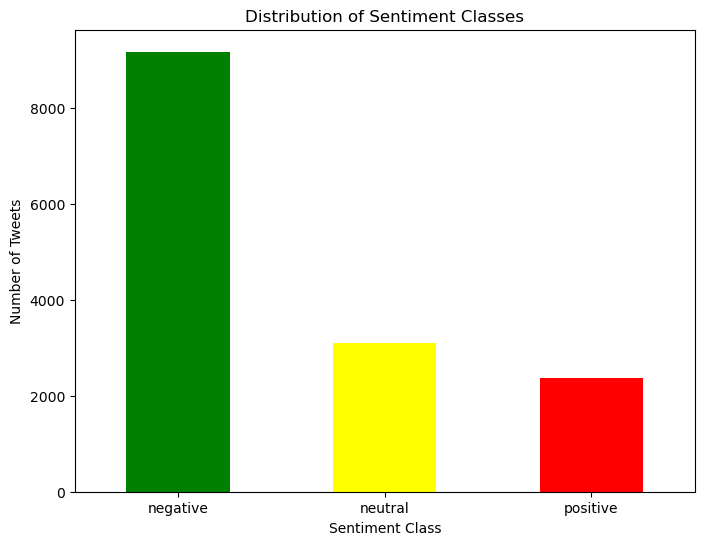

In [6]:
# Visualize the distribution of sentiment classes.
# Count the occurrences of each sentiment class
sentiment_counts = df['airline_sentiment'].value_counts()

# Plotting the distribution
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'yellow', 'red'])
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()


C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_11628\857852904.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(num_neg, shade=True, color = 'r').set_title('Kernel distribution of number of words')
C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_11628\857852904.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(num_neu, shade=True, color = 'y')
C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_11628\857852904.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(num_pos, shade=True, color = 'b')


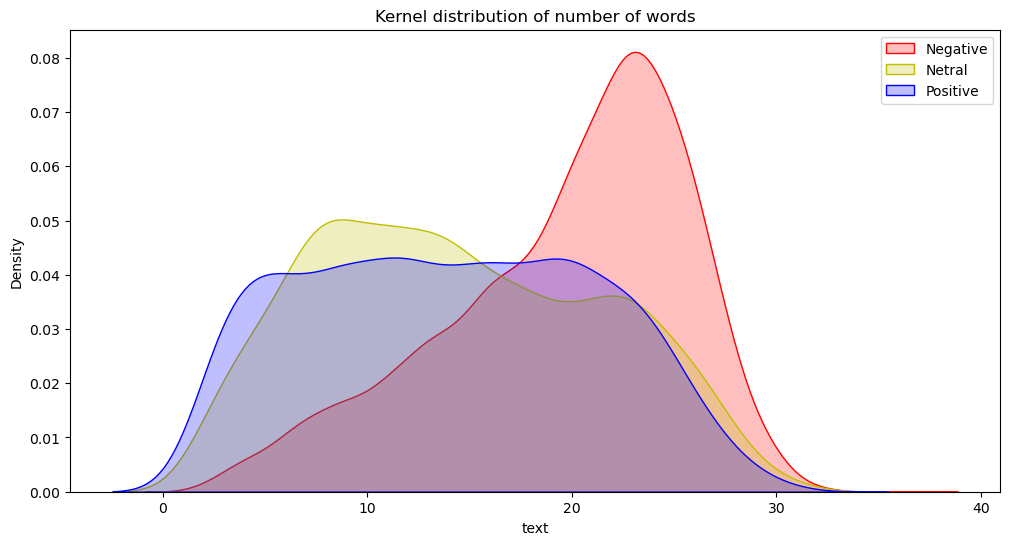

In [7]:
num_neg = df[df['airline_sentiment']=='negative']['text'].apply(lambda x: len(x.split()))
num_neu = df[df['airline_sentiment']=='neutral']['text'].apply(lambda x: len(x.split()))
num_pos = df[df['airline_sentiment']=='positive']['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(12,6))
sns.kdeplot(num_neg, shade=True, color = 'r').set_title('Kernel distribution of number of words')
sns.kdeplot(num_neu, shade=True, color = 'y')
sns.kdeplot(num_pos, shade=True, color = 'b')

plt.legend(labels=['Negative', 'Netral','Positive'])

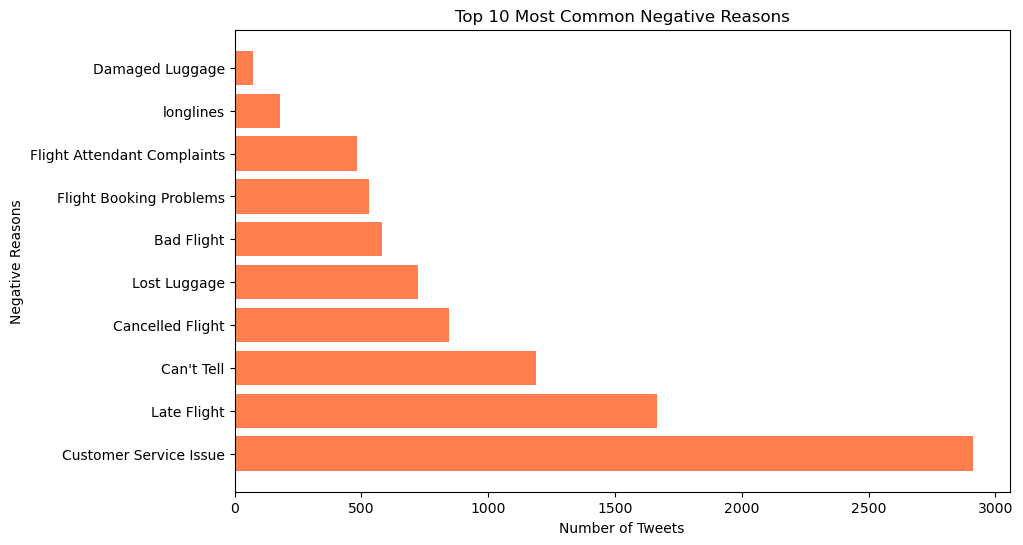

In [8]:
#Explore the most common negative reasons mentioned in the dataset
# Filter rows with negative sentiment
negative_tweets = df[df['airline_sentiment'] == 'negative']

# Extract the negative reasons
negative_reasons = negative_tweets['negativereason'].dropna()  # Drop NaN values if any

# Count the occurrences of each negative reason
reason_counts = Counter(negative_reasons)

# Plotting the most common negative reasons
plt.figure(figsize=(10, 6))
reason_counts.most_common(10).sort(key=lambda x: x[1], reverse=True)
reasons, counts = zip(*reason_counts.most_common(10))
plt.barh(reasons, counts, color='coral')
plt.title('Top 10 Most Common Negative Reasons')
plt.xlabel('Number of Tweets')
plt.ylabel('Negative Reasons')
plt.show()

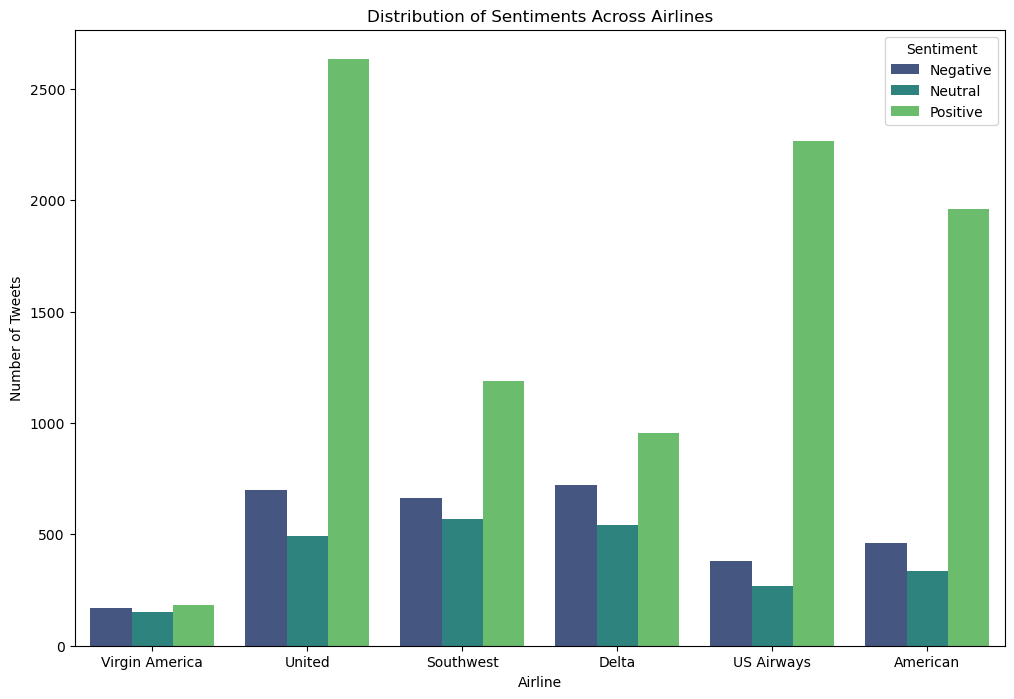

In [9]:
#Analyze the distribution of sentiments across different airlines
# Create a grouped bar plot
plt.figure(figsize=(12, 8))
sns.countplot(x='airline', hue='airline_sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments Across Airlines')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment', loc='upper right', labels=['Negative', 'Neutral', 'Positive'])
plt.show()


# Text Cleaning and Normalization

In [10]:
import re

# Function to preprocess text
def preprocess_text(text):
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    # Remove special characters and numbers
    text = re.sub(r"[^\w\s]", "", text)
    # Remove extra whitespaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply the preprocessing function to the 'text' column
df['text'] = df['text'].apply(preprocess_text)

# Display the updated DataFrame
print(df['text'])


0                         VirginAmerica What dhepburn said
1        VirginAmerica plus youve added commercials to ...
2        VirginAmerica I didnt today Must mean I need t...
3        VirginAmerica its really aggressive to blast o...
4        VirginAmerica and its a really big bad thing a...
                               ...                        
14635    AmericanAir thank you we got on a different fl...
14636    AmericanAir leaving over 20 minutes Late Fligh...
14637    AmericanAir Please bring American Airlines to ...
14638    AmericanAir you have my money you change my fl...
14639    AmericanAir we have 8 ppl so we need 2 know ho...
Name: text, Length: 14640, dtype: object


In [11]:
# Function to tokenize text
def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

# Apply the tokenization function to the 'text' column
df['tokens'] = df['text'].apply(tokenize_text)

# Display the updated DataFrame with tokenized text
print(df[['text', 'tokens']])


                                                    text  \
0                       VirginAmerica What dhepburn said   
1      VirginAmerica plus youve added commercials to ...   
2      VirginAmerica I didnt today Must mean I need t...   
3      VirginAmerica its really aggressive to blast o...   
4      VirginAmerica and its a really big bad thing a...   
...                                                  ...   
14635  AmericanAir thank you we got on a different fl...   
14636  AmericanAir leaving over 20 minutes Late Fligh...   
14637  AmericanAir Please bring American Airlines to ...   
14638  AmericanAir you have my money you change my fl...   
14639  AmericanAir we have 8 ppl so we need 2 know ho...   

                                                  tokens  
0                  [VirginAmerica, What, dhepburn, said]  
1      [VirginAmerica, plus, youve, added, commercial...  
2      [VirginAmerica, I, didnt, today, Must, mean, I...  
3      [VirginAmerica, its, really, aggress

In [12]:

# Function to perform lemmatization
def lemmatize_text(tokens):
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens

# Tokenize the 'text' column
df['tokens'] = df['text'].apply(word_tokenize)

# Apply lemmatization to the tokenized text
df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_text)

# Display the updated DataFrame with lemmatized tokens
print(df[['text', 'tokens', 'lemmatized_tokens']])


                                                    text  \
0                       VirginAmerica What dhepburn said   
1      VirginAmerica plus youve added commercials to ...   
2      VirginAmerica I didnt today Must mean I need t...   
3      VirginAmerica its really aggressive to blast o...   
4      VirginAmerica and its a really big bad thing a...   
...                                                  ...   
14635  AmericanAir thank you we got on a different fl...   
14636  AmericanAir leaving over 20 minutes Late Fligh...   
14637  AmericanAir Please bring American Airlines to ...   
14638  AmericanAir you have my money you change my fl...   
14639  AmericanAir we have 8 ppl so we need 2 know ho...   

                                                  tokens  \
0                  [VirginAmerica, What, dhepburn, said]   
1      [VirginAmerica, plus, youve, added, commercial...   
2      [VirginAmerica, I, didnt, today, Must, mean, I...   
3      [VirginAmerica, its, really, agg

In [13]:
# Check for missing values in all columns
missing_values = df.isnull().sum()

# Display the count of missing values in each column
print(missing_values)

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
tokens                              0
lemmatized_tokens                   0
dtype: int64


In [14]:

numerical_columns = ['negativereason_confidence']
categorical_columns = ['negativereason', 'airline_sentiment_gold', 'negativereason_gold', 'tweet_location', 'user_timezone','tweet_coord']

numerical_imputer = SimpleImputer(strategy='mean')
categorical_imputer = SimpleImputer(strategy='most_frequent')

df[numerical_columns] = numerical_imputer.fit_transform(df[numerical_columns])
df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])


In [15]:
# Check for missing values in all columns
missing_values = df.isnull().sum()

# Display the count of missing values in each column
print(missing_values)

tweet_id                        0
airline_sentiment               0
airline_sentiment_confidence    0
negativereason                  0
negativereason_confidence       0
airline                         0
airline_sentiment_gold          0
name                            0
negativereason_gold             0
retweet_count                   0
text                            0
tweet_coord                     0
tweet_created                   0
tweet_location                  0
user_timezone                   0
tokens                          0
lemmatized_tokens               0
dtype: int64


In [16]:
df = df.drop(['tokens', 'lemmatized_tokens'], axis=1)
df=df.drop('airline_sentiment_gold',axis=1)
df=df.drop('negativereason_gold',axis=1)

In [17]:
# Check for duplicated rows
df.duplicated().sum()


39

In [18]:
df=df.drop_duplicates()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14601 entries, 0 to 14639
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14601 non-null  int64  
 1   airline_sentiment             14601 non-null  object 
 2   airline_sentiment_confidence  14601 non-null  float64
 3   negativereason                14601 non-null  object 
 4   negativereason_confidence     14601 non-null  float64
 5   airline                       14601 non-null  object 
 6   name                          14601 non-null  object 
 7   retweet_count                 14601 non-null  int64  
 8   text                          14601 non-null  object 
 9   tweet_coord                   14601 non-null  object 
 10  tweet_created                 14601 non-null  object 
 11  tweet_location                14601 non-null  object 
 12  user_timezone                 14601 non-null  object 
dtypes: flo

# Feature Extraction:

In [20]:
# Function to tokenize text
def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

# Apply the tokenization function to the 'text' column
df['tokens'] = df['text'].apply(tokenize_text)


In [21]:

# Combine the 'text' column if it's tokenized or lemmatized
# If not, you can directly use 'df['text']' in the Word2Vec model
df['combined_text'] = df['tokens'].apply(lambda x: ' '.join(x))

# Tokenize the combined text
tokenized_text = [text.split() for text in df['combined_text']]

# Remove stopwords
stop_words = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)
tokenized_text = [[word for word in text if word.lower() not in stop_words] for text in tokenized_text]

# Train a Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=1, workers=4)

# Function to get the average vector for a document
def get_average_vector(tokens, model, vector_size):
    if len(tokens) == 0:
        return np.zeros(vector_size)
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0)

# Get Word2Vec features for each document
word2vec_features = df['tokens'].apply(lambda x: get_average_vector(x, word2vec_model, 100))

# Convert the Word2Vec features to a DataFrame
word2vec_df = pd.DataFrame(word2vec_features.tolist(), columns=[f'w2v_{i}' for i in range(100)])

# Concatenate the Word2Vec features with the original DataFrame
df = pd.concat([df, word2vec_df], axis=1)

# Drop the temporary 'combined_text' column
df.drop(['combined_text'], axis=1, inplace=True)

# Display the DataFrame with Word2Vec features
print(df)


           tweet_id airline_sentiment  airline_sentiment_confidence  \
0      5.703061e+17           neutral                        1.0000   
1      5.703011e+17          positive                        0.3486   
2      5.703011e+17           neutral                        0.6837   
3      5.703010e+17          negative                        1.0000   
4      5.703008e+17          negative                        1.0000   
...             ...               ...                           ...   
12159           NaN               NaN                           NaN   
12162           NaN               NaN                           NaN   
12196           NaN               NaN                           NaN   
13864           NaN               NaN                           NaN   
14392           NaN               NaN                           NaN   

               negativereason  negativereason_confidence         airline  \
0      Customer Service Issue                   0.638298  Virgin Americ

In [111]:
from sklearn.feature_extraction.text import CountVectorizer

# Assuming your dataset is loaded into a DataFrame called 'df'
# Replace 'df' with the actual variable name if different

# Convert lists of tokens to strings, handling missing values
df['combined_text'] = df['tokens'].apply(lambda x: ' '.join(map(str, x)) if isinstance(x, list) else '')

# Create a Count Vectorizer
count_vectorizer = CountVectorizer()

# Fit and transform the text data
count_matrix = count_vectorizer.fit_transform(df['combined_text'])

# Convert the Count matrix to a DataFrame
count_df = pd.DataFrame(count_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

# Concatenate the Count features with the original DataFrame
df = pd.concat([df, count_df], axis=1)

# Drop the temporary 'combined_text' column
df.drop(['combined_text'], axis=1, inplace=True)

# Display the DataFrame with Count Vectorization features
print(df)


           tweet_id airline_sentiment  airline_sentiment_confidence  \
0      5.703061e+17           neutral                        1.0000   
1      5.703011e+17          positive                        0.3486   
2      5.703011e+17           neutral                        0.6837   
3      5.703010e+17          negative                        1.0000   
4      5.703008e+17          negative                        1.0000   
...             ...               ...                           ...   
12158           NaN               NaN                           NaN   
12159           NaN               NaN                           NaN   
12162           NaN               NaN                           NaN   
13864           NaN               NaN                           NaN   
14392           NaN               NaN                           NaN   

               negativereason  negativereason_confidence         airline  \
0      Customer Service Issue                   0.638298  Virgin Americ

# Apply Part-of-Speech Tagging

In [46]:
def pos_tagging(text):
    # Check if the value is not NaN and is a string
    if pd.notna(text) and isinstance(text, str):
        # Tokenize the text into words
        words = word_tokenize(text)
        # Apply POS tagging to the list of words
        return nltk.pos_tag(words)
    else:
        return []
# Apply the POS tagging function to the 'text' column
df['text_POS_tagged'] = df['text'].apply(pos_tagging)
print(df['text_POS_tagged'].head(10))

0    [(VirginAmerica, NNP), (What, WP), (dhepburn, ...
1    [(VirginAmerica, NNP), (plus, CC), (youve, NN)...
2    [(VirginAmerica, NNP), (I, PRP), (didnt, VBP),...
3    [(VirginAmerica, NNP), (its, PRP$), (really, R...
4    [(VirginAmerica, NNP), (and, CC), (its, PRP$),...
5    [(VirginAmerica, NNP), (seriously, RB), (would...
6    [(VirginAmerica, NNP), (yes, RB), (nearly, RB)...
7    [(VirginAmerica, NNP), (Really, NNP), (missed,...
8    [(virginamerica, RB), (Well, NNP), (I, PRP), (...
9    [(VirginAmerica, NNP), (it, PRP), (was, VBD), ...
Name: text_POS_tagged, dtype: object


In [42]:
df['negativereason'] = df['negativereason'].astype(str)
def pos_tagging(text):
    # Tokenize the text into words
    words = word_tokenize(text)
    # Apply POS tagging to the words list
    return nltk.pos_tag(words)

# Apply the POS tagging function to the 'negativereason' column
df['negativereason_POS'] = df['negativereason'].apply(pos_tagging)
# Now 'negativereason_POS' column has the POS tagging information
print(df[['negativereason_POS']].head(5))

                                negativereason_POS
0  [(Customer, NNP), (Service, NNP), (Issue, NNP)]
1  [(Customer, NNP), (Service, NNP), (Issue, NNP)]
2  [(Customer, NNP), (Service, NNP), (Issue, NNP)]
3                      [(Bad, NNP), (Flight, NNP)]
4               [(Ca, NNP), (n't, RB), (Tell, VB)]


In [49]:
df['tweet_location'] = df['tweet_location'].astype(str)
def pos_tagging(text):
    # Tokenize the text into words
    words = word_tokenize(text)
    # Apply POS tagging to the words list
    return nltk.pos_tag(words)

# Apply the POS tagging function to the 'negativereason' column
df['POS'] = df['tweet_location'].apply(pos_tagging)
# Now 'negativereason_POS' column has the POS tagging information
print(df[['POS']].head(5))

                                  POS
0  [(Boston, NNP), (,, ,), (MA, NNP)]
1  [(Boston, NNP), (,, ,), (MA, NNP)]
2          [(Lets, NNS), (Play, VBP)]
3  [(Boston, NNP), (,, ,), (MA, NNP)]
4  [(Boston, NNP), (,, ,), (MA, NNP)]
